In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#For pretty display of all plots
import warnings
warnings.filterwarnings("ignore")

#Load Cleaned Dataset (Full Path)
file_path = r"C:\My stuff\Coding\ML project\KiranveerSingh_Project\Dataset\cleaned_nutrition_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded!")
print(f"Shape: {df.shape}")
print("Columns:\n", df.columns.tolist())



Dataset Loaded!
Shape: (1000, 1096)
Columns:
 ['Age', 'Height_(cm)', 'Weight_(kg)', 'BMI', 'Daily_Calorie_Intake', 'Daily_Protein_Intake_(g)', 'Daily_Fat_Intake_(g)', 'Daily_Carbohydrate_Intake_(g)', 'Daily_Fiber_Intake_(g)', 'Daily_Water_Intake_(liters)', 'Vitamin_A_Intake_(mcg)', 'Vitamin_B1_(Thiamine)_Intake_(mg)', 'Vitamin_B2_(Riboflavin)_Intake_(mg)', 'Vitamin_B3_(Niacin)_Intake_(mg)', 'Vitamin_B5_(Pantothenic_Acid)_Intake_(mg)', 'Vitamin_B6_Intake_(mg)', 'Vitamin_B12_Intake_(mcg)', 'Vitamin_C_Intake_(mg)', 'Vitamin_D_Intake_(IU)', 'Vitamin_E_Intake_(mg)', 'Vitamin_K_Intake_(mcg)', 'Iron_Intake_(mg)', 'Zinc_Intake_(mg)', 'Magnesium_Intake_(mg)', 'Calcium_Intake_(mg)', 'Iodine_Intake_(mcg)', 'Selenium_Intake_(mcg)', 'Copper_Intake_(mg)', 'Folate_(Folic_Acid)_Intake_(mcg)', 'Phosphorus_Intake_(mg)', 'Manganese_Intake_(mg)', 'Chromium_Intake_(mcg)', 'Food_Diversity_Score', 'Hemoglobin_(g/dL)', 'Serum_Ferritin_(ng/mL)', 'Vitamin_D_25-OH_(ng/mL)', 'Serum_B12_(pg/mL)', 'Serum_Folate_(ng

In [2]:

#Identify Numeric & Categorical Columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f"\n Numeric Columns: {len(numeric_cols)} found.")
print(f" Categorical Columns: {len(categorical_cols)} found.")






 Numeric Columns: 45 found.
 Categorical Columns: 0 found.


In [3]:
sns.set(style="whitegrid")
plt.rcParams.update({'figure.max_open_warning': 0})


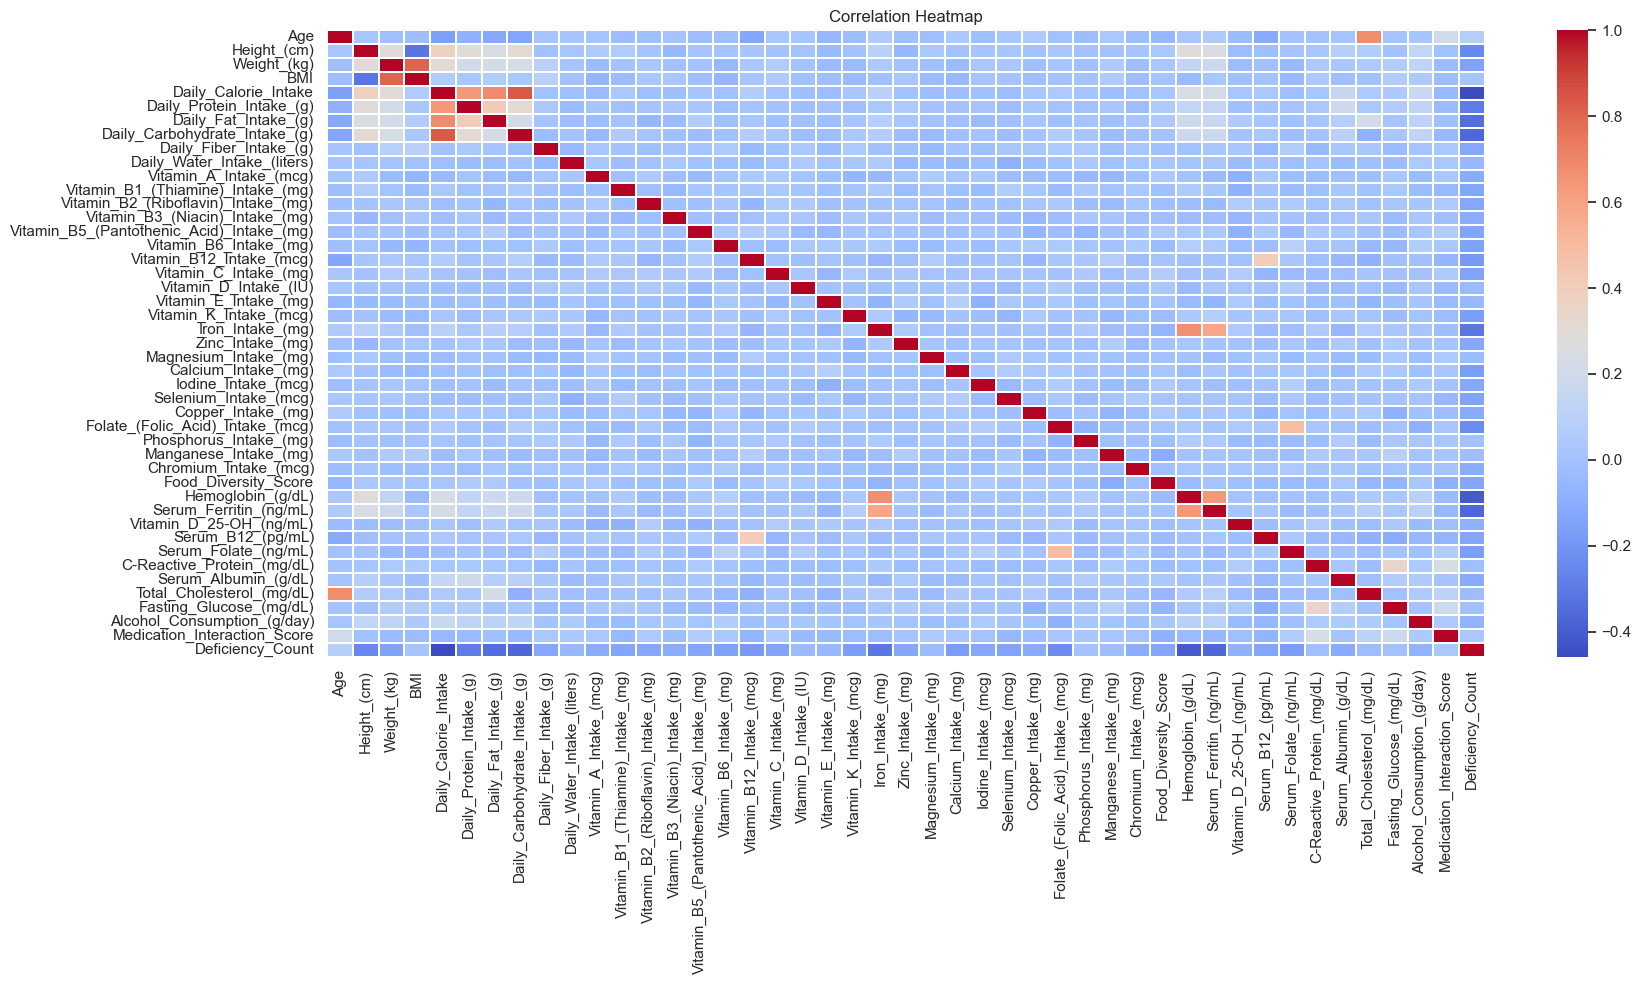

In [4]:
#Heatmap (Correlation Between Numeric Variables)
plt.figure(figsize=(18, 10))
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap="coolwarm", linewidths=0.3)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

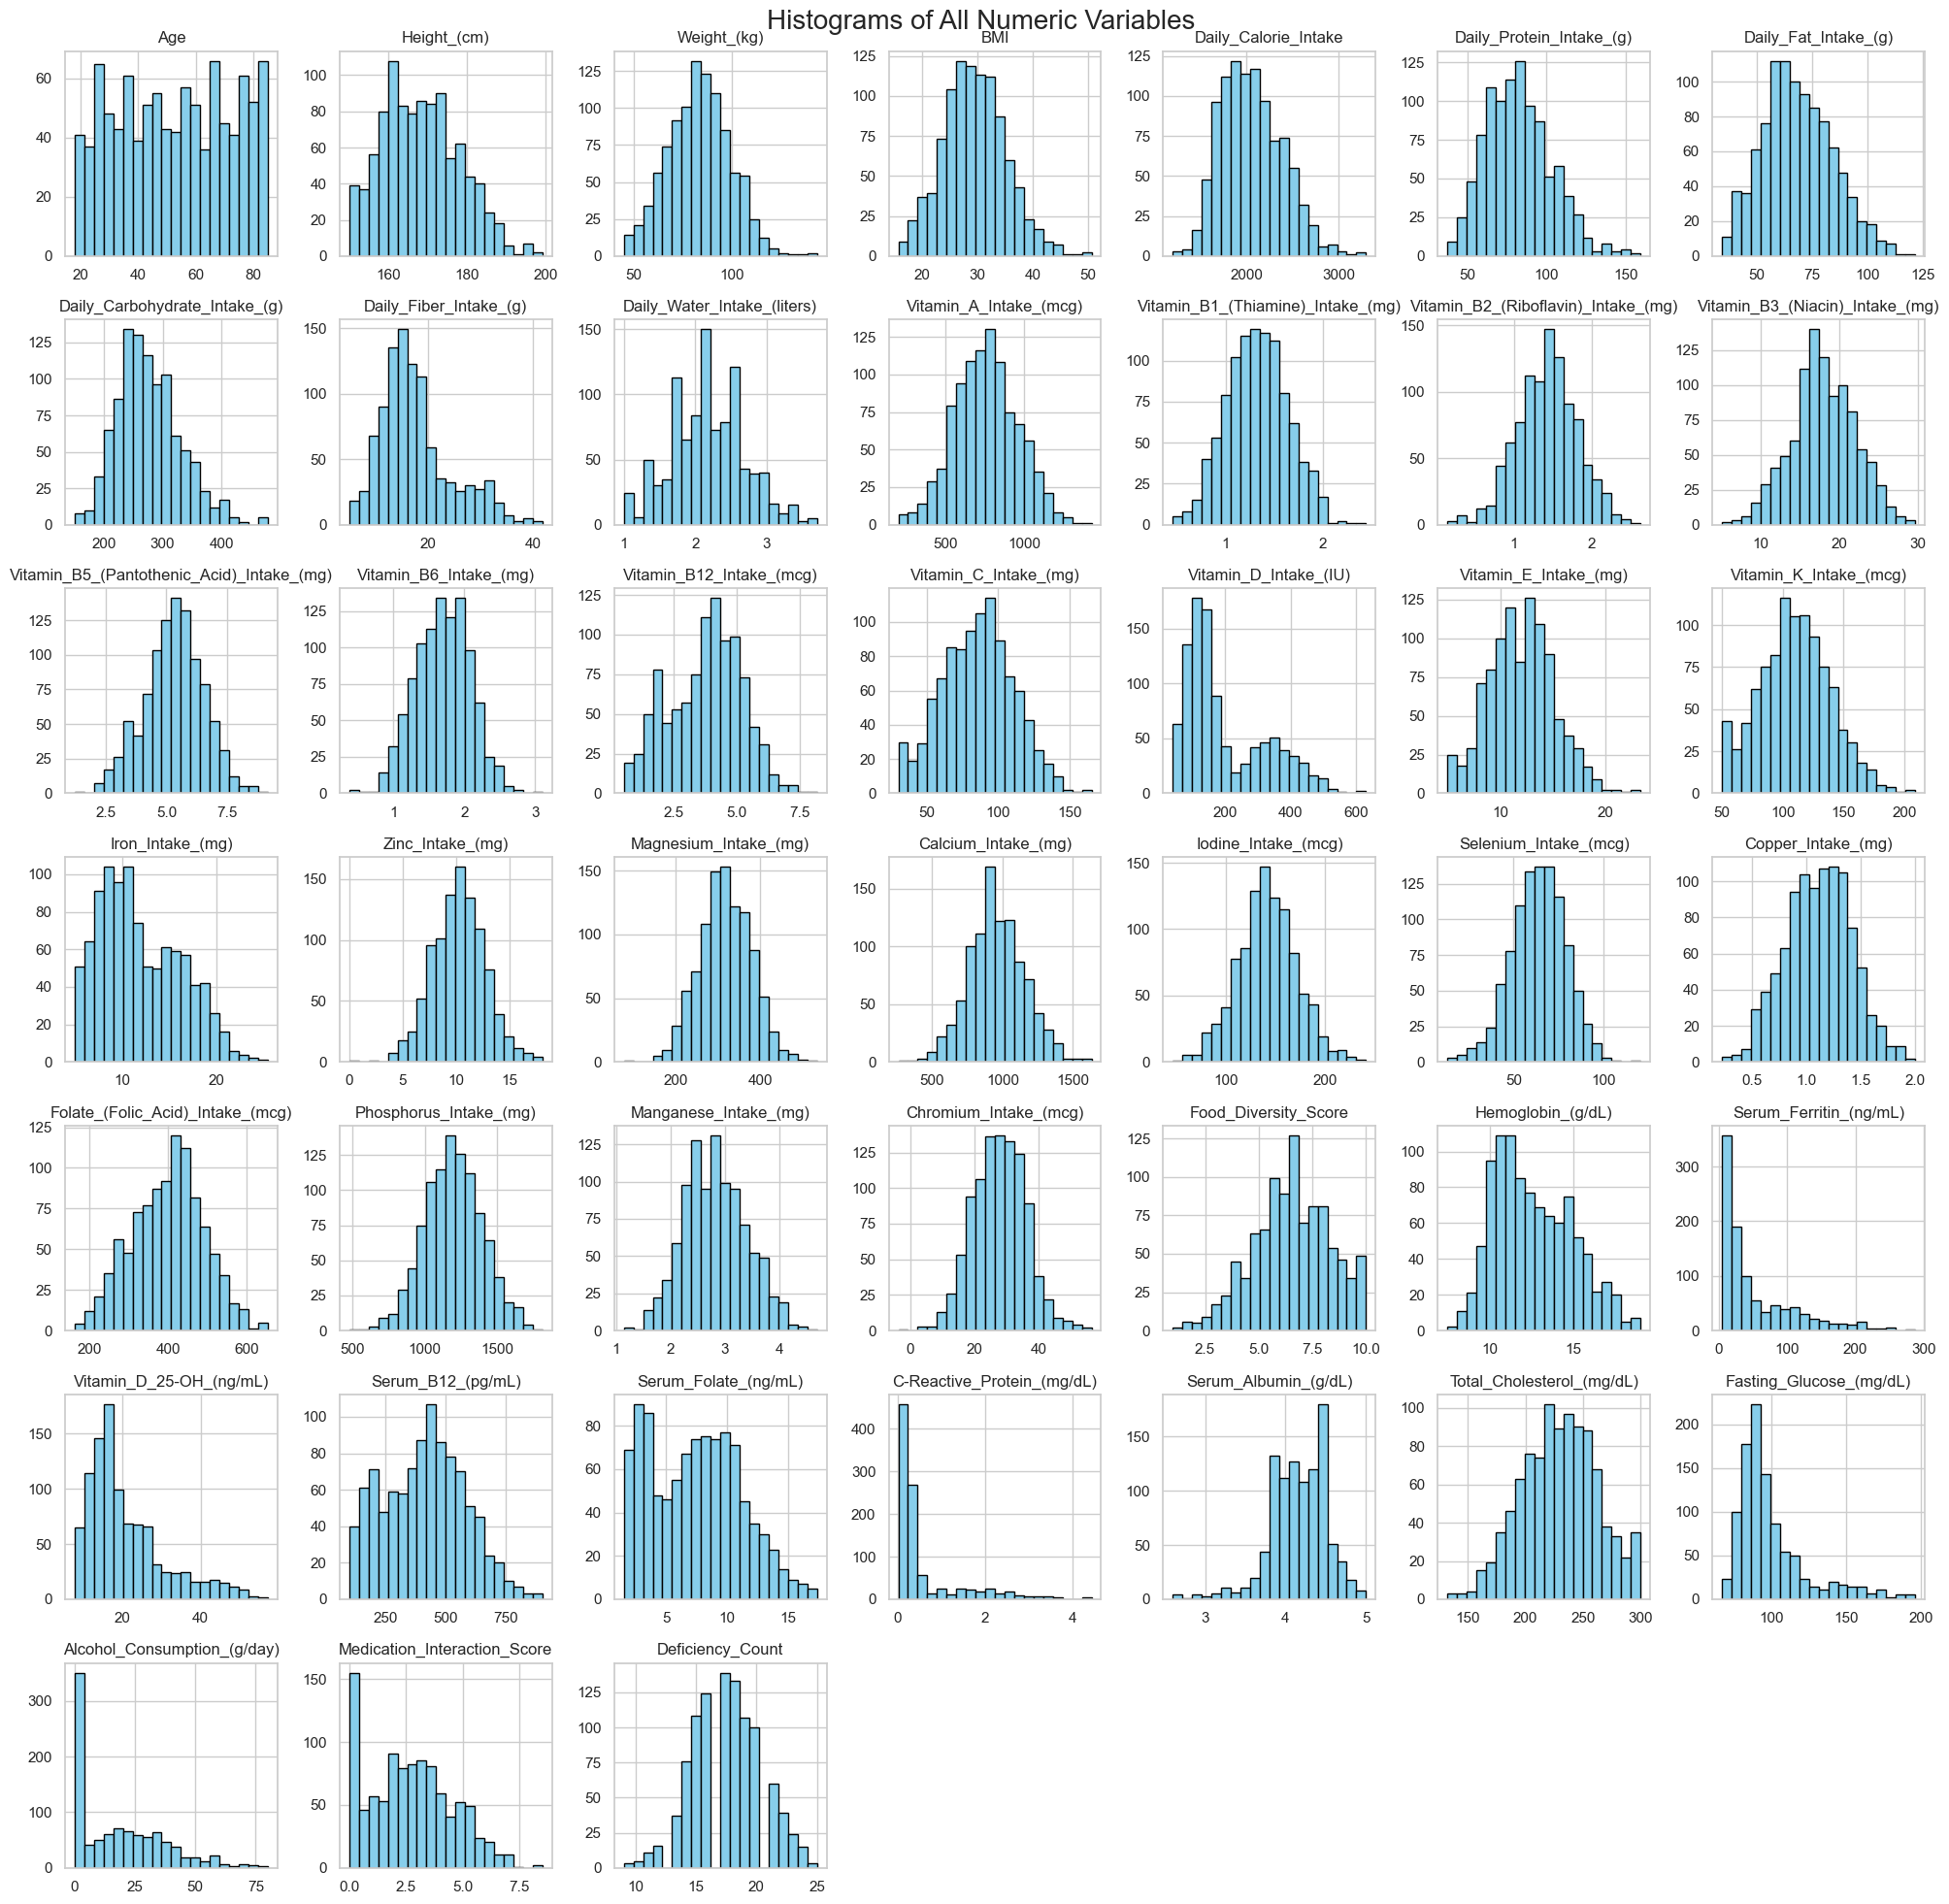

In [5]:
#Histograms for All Numeric Columns
df[numeric_cols].hist(bins=20, figsize=(20, 20), color='skyblue', edgecolor='black')
plt.suptitle("Histograms of All Numeric Variables", fontsize=20)
plt.tight_layout()
plt.show()


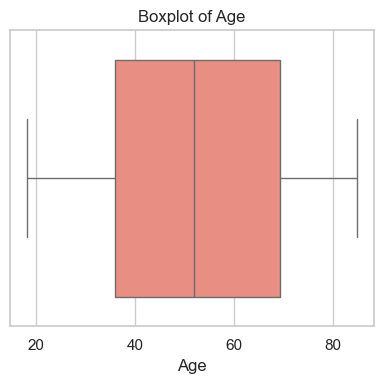

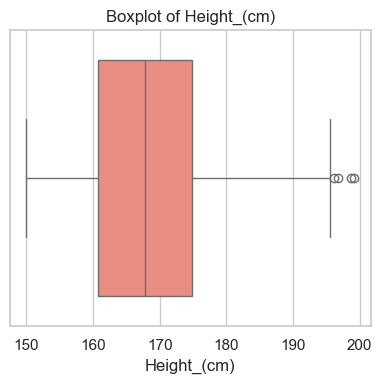

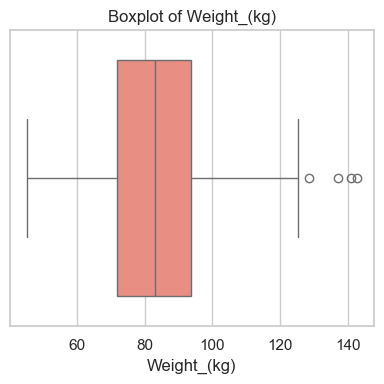

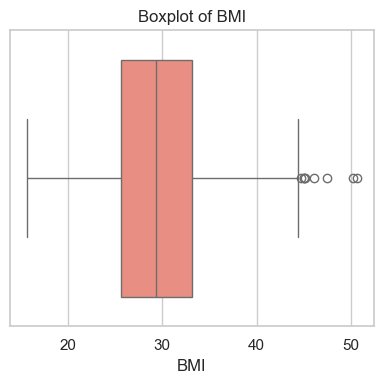

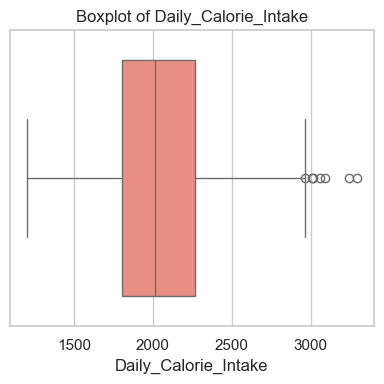

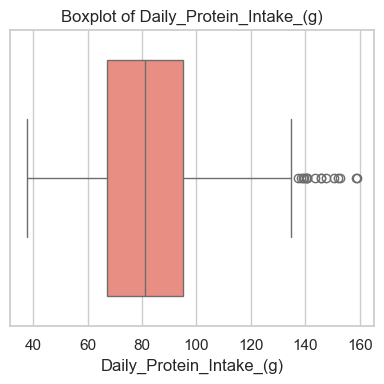

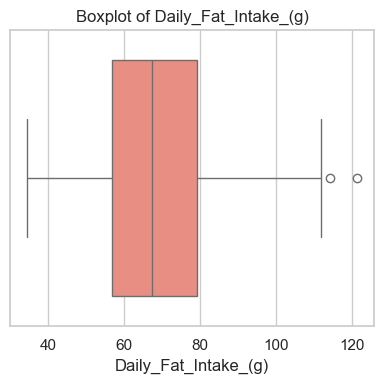

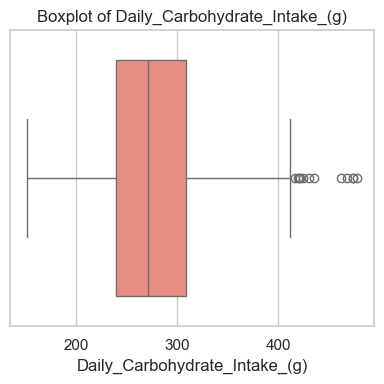

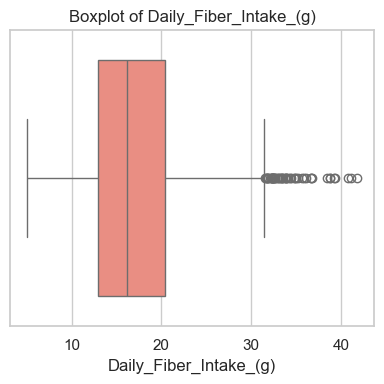

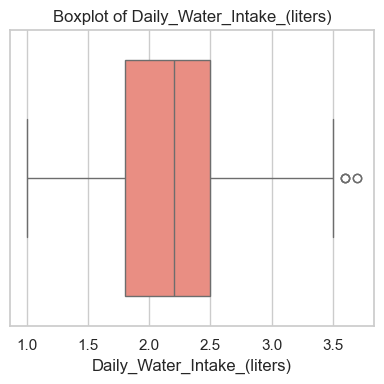

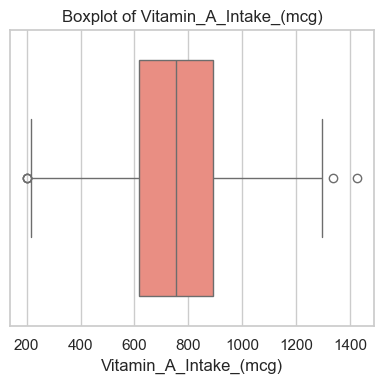

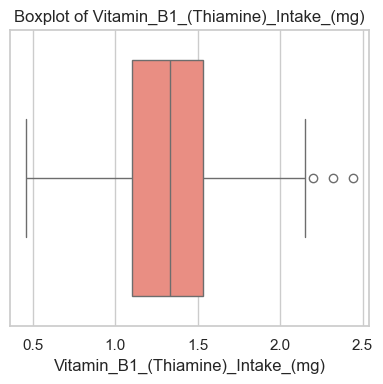

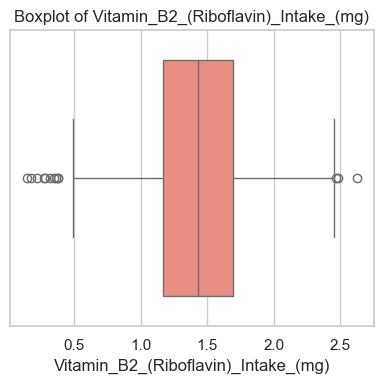

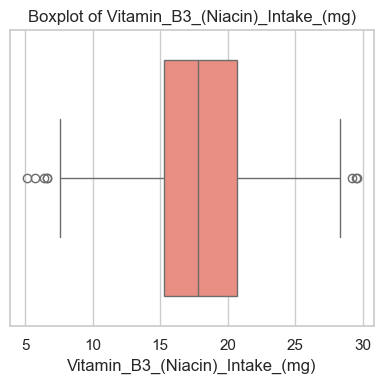

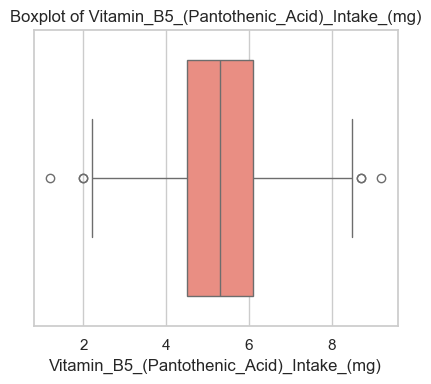

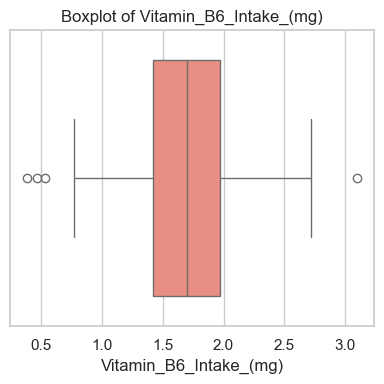

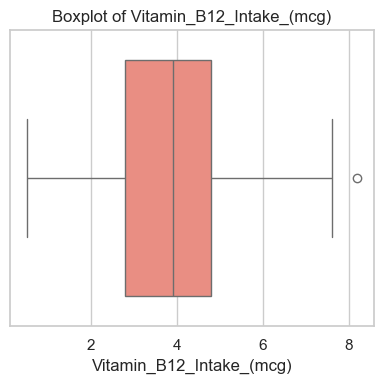

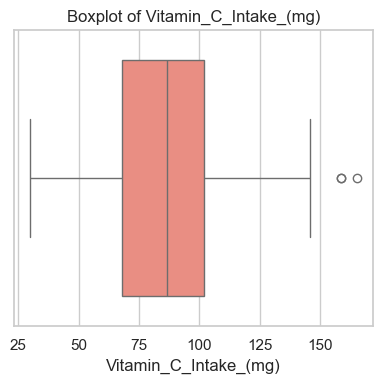

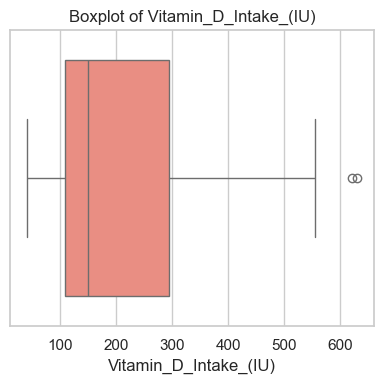

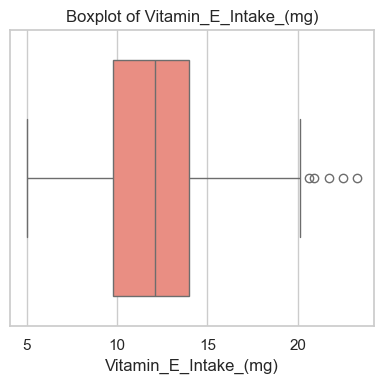

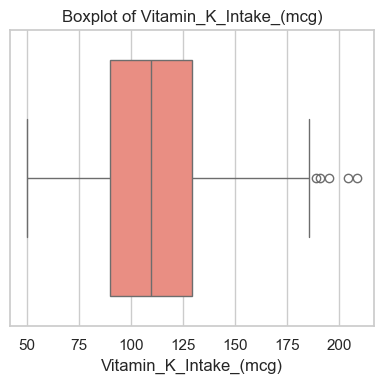

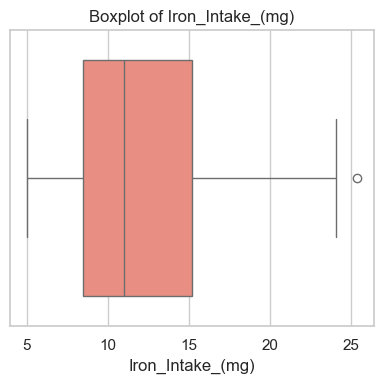

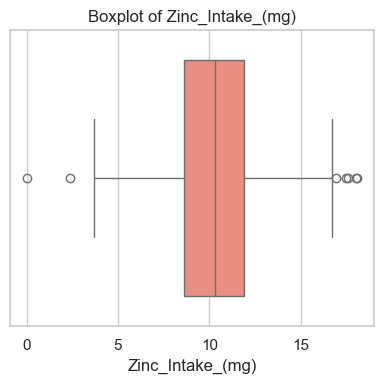

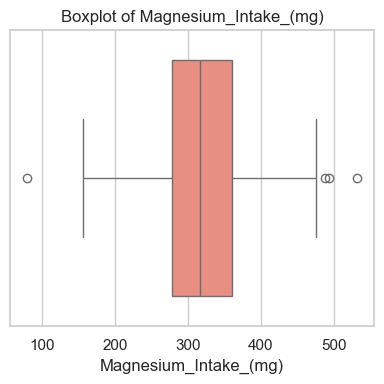

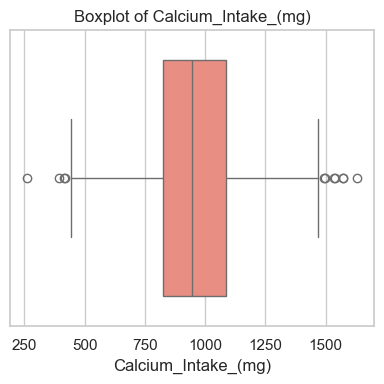

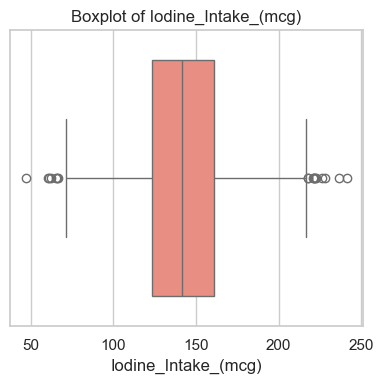

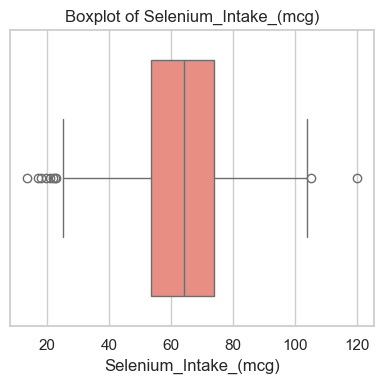

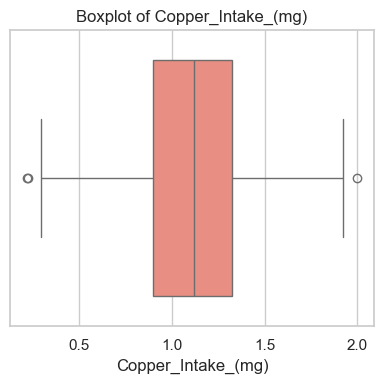

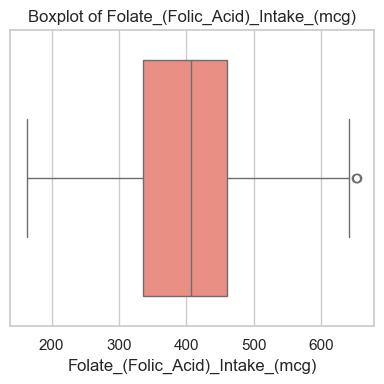

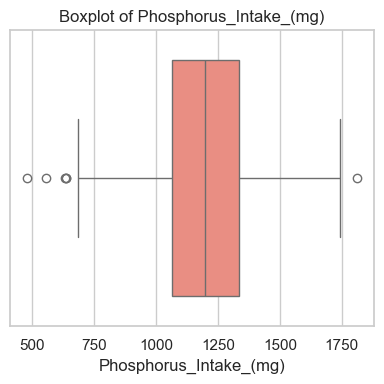

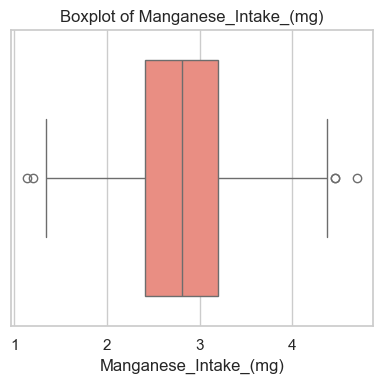

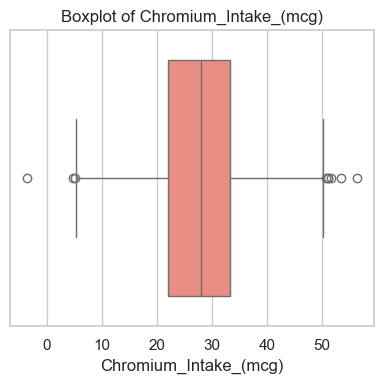

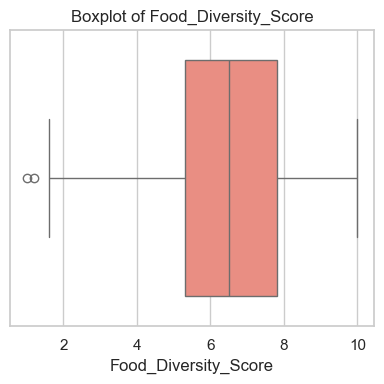

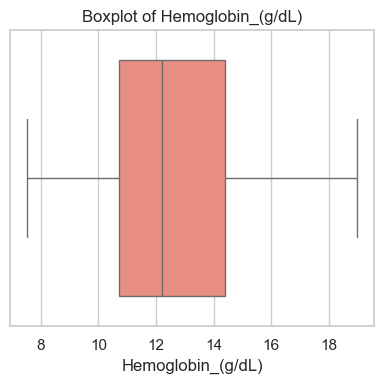

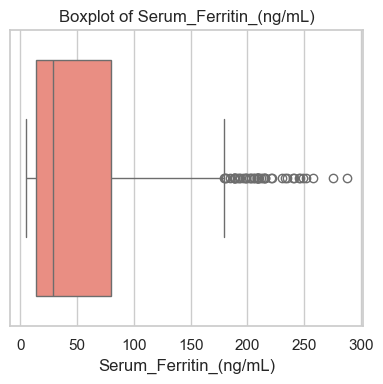

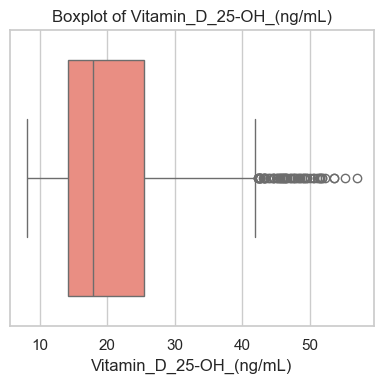

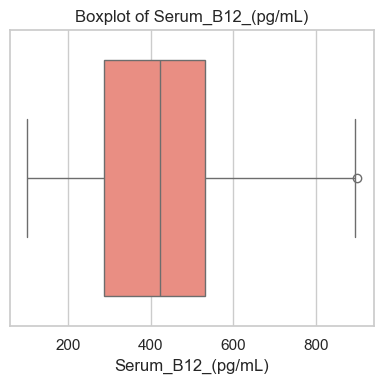

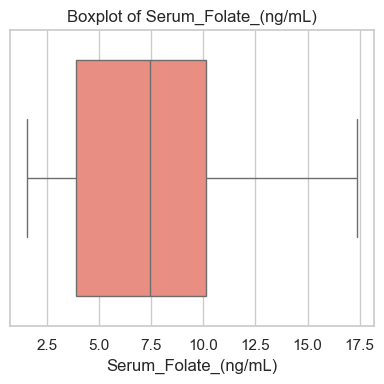

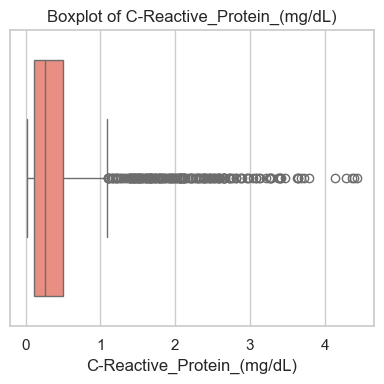

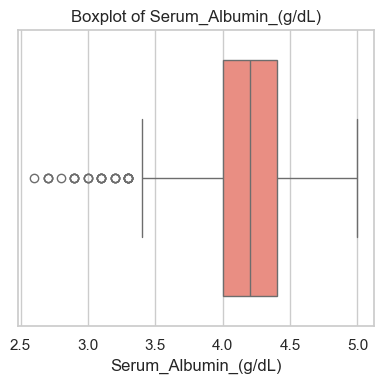

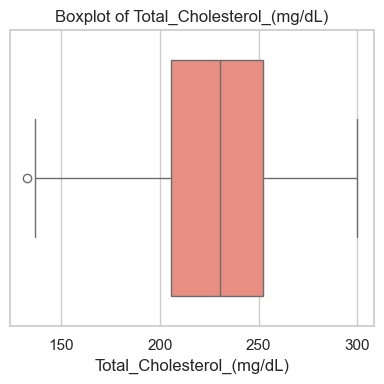

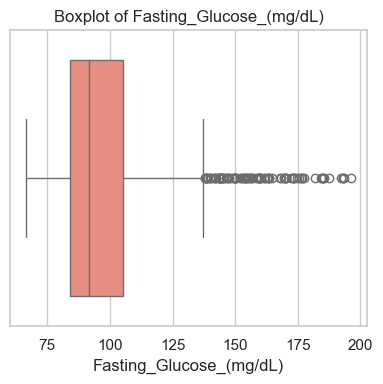

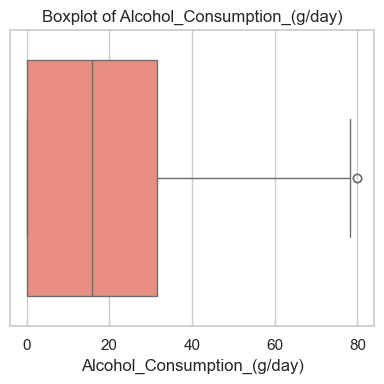

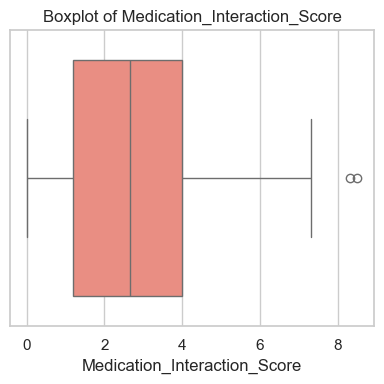

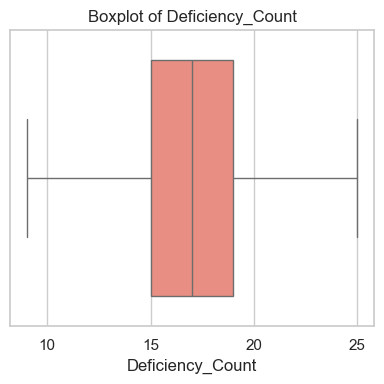

In [6]:

#Boxplots for All Numeric Columns
for col in numeric_cols:
    plt.figure(figsize=(4, 4))
    sns.boxplot(x=df[col], color='salmon')
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()



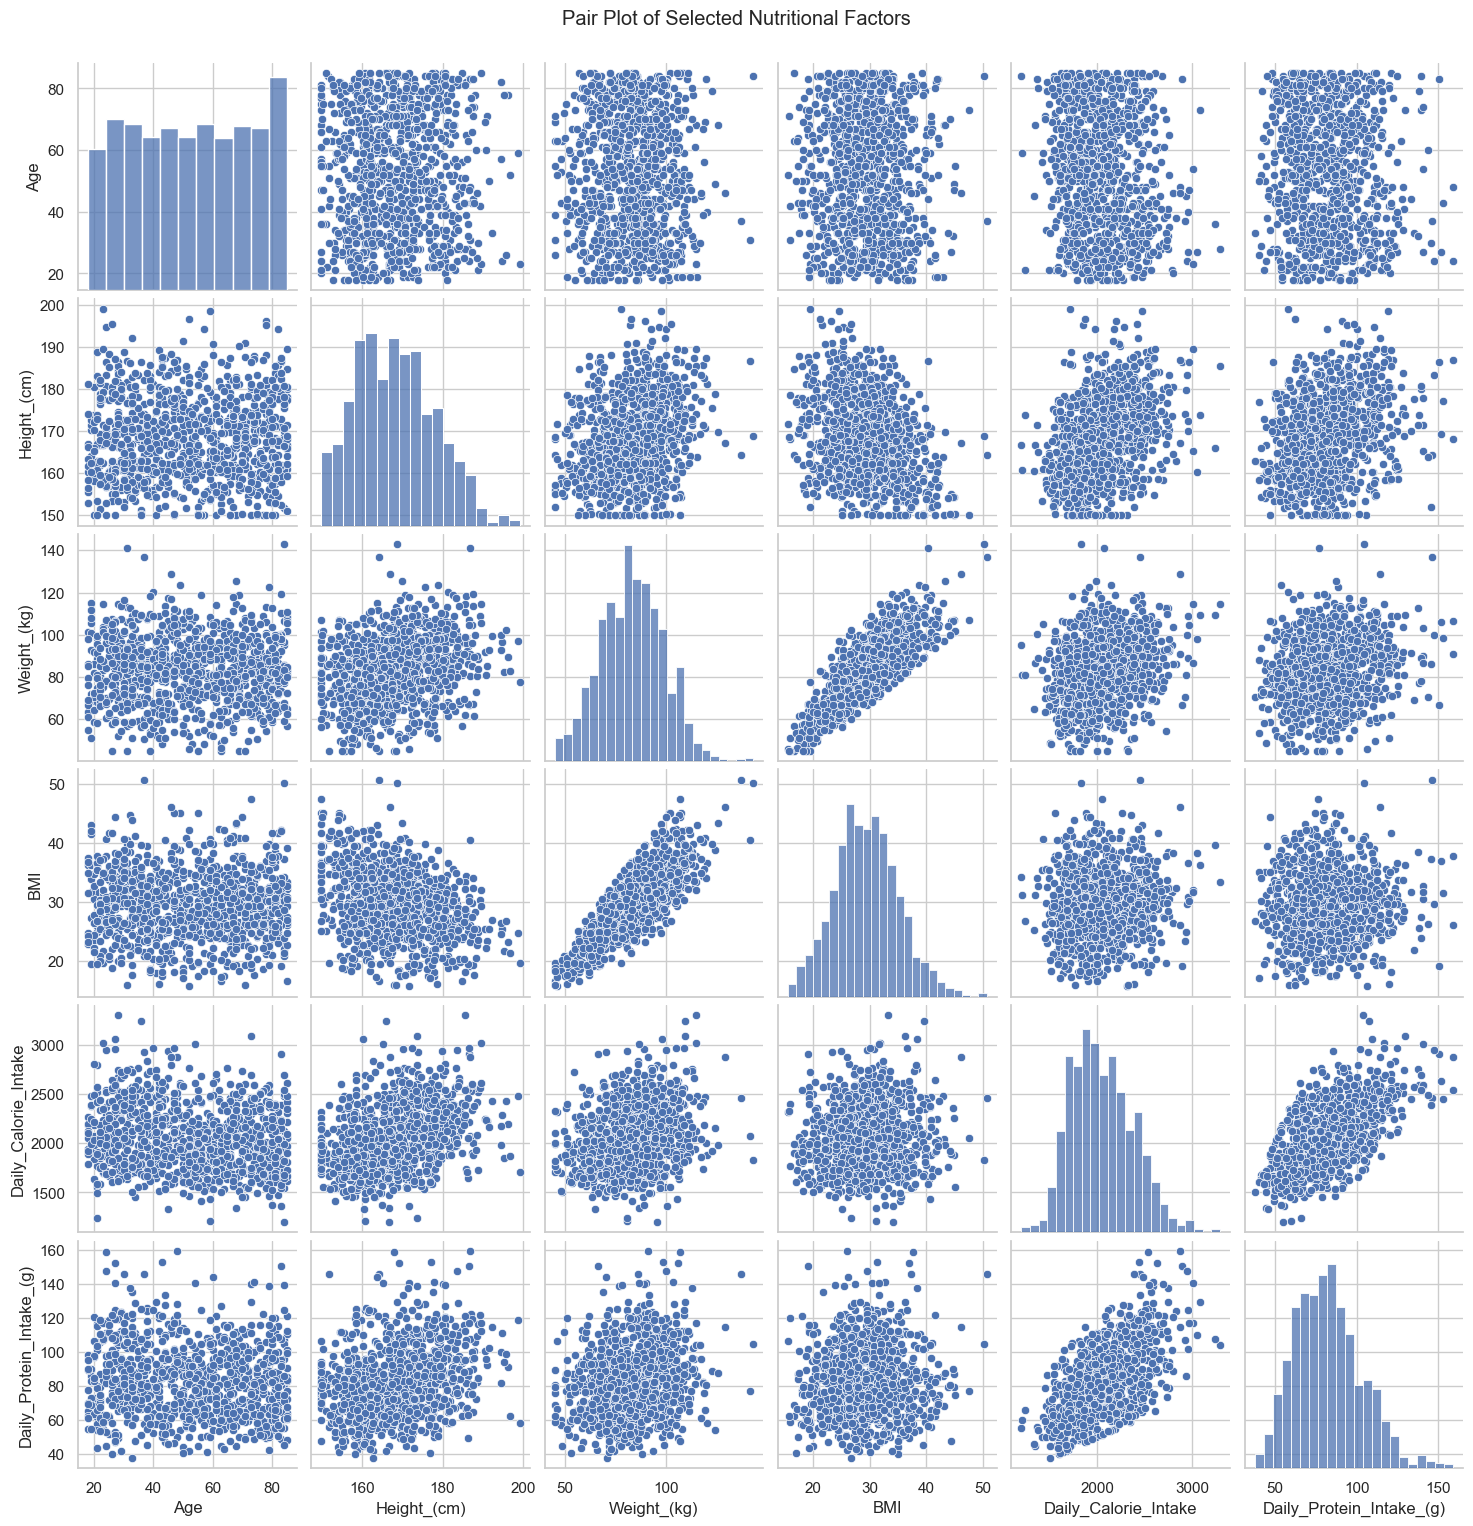

In [7]:

#Pairplot (Multivariate Relationships)
# Limit to 6-8 variables to avoid overload
subset_cols = numeric_cols[:6]  # change if you prefer different set
sns.pairplot(df[subset_cols])
plt.suptitle("Pair Plot of Selected Nutritional Factors", y=1.02)
plt.show()


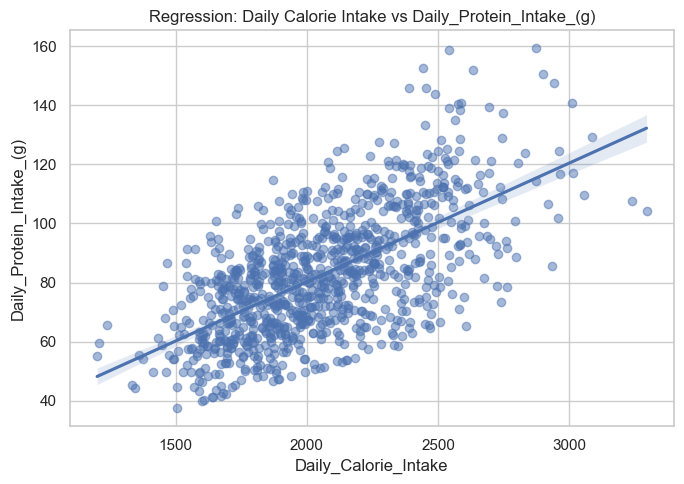

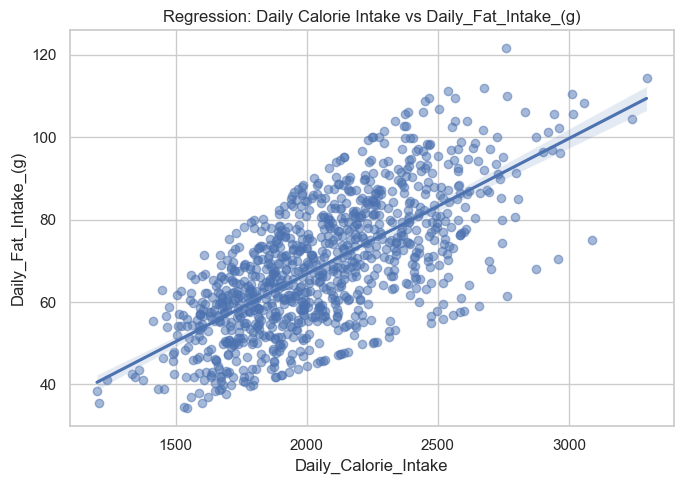

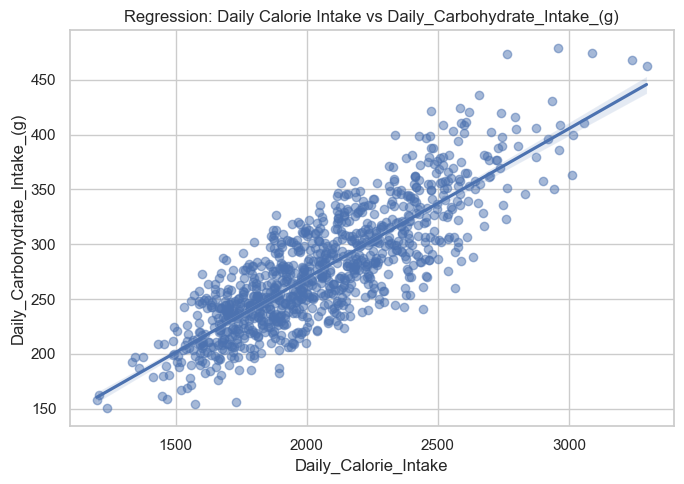

In [8]:
#Regression Plots (Calorie vs Macros Example)
if 'Daily_Calorie_Intake' in df.columns:
    for col in ['Daily_Protein_Intake_(g)', 'Daily_Fat_Intake_(g)', 'Daily_Carbohydrate_Intake_(g)']:
        if col in df.columns:
            plt.figure(figsize=(7, 5))
            sns.regplot(x='Daily_Calorie_Intake', y=col, data=df, scatter_kws={"alpha":0.5})
            plt.title(f"Regression: Daily Calorie Intake vs {col}")
            plt.tight_layout()
            plt.show()

In [9]:
def column_exists(col):
    return col in df.columns

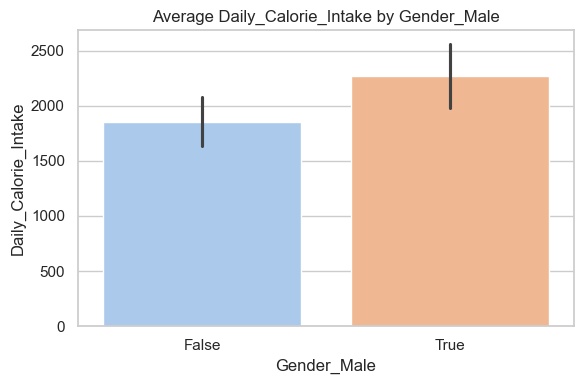

In [10]:
gender_col = next((col for col in df.columns if "gender" in col.lower()), None)
calorie_col = next((col for col in df.columns if "calorie" in col.lower()), None)

if gender_col and calorie_col:
    plt.figure(figsize=(6, 4))
    sns.barplot(data=df, x=gender_col, y=calorie_col, estimator='mean', ci='sd', palette='pastel')
    plt.title(f"Average {calorie_col} by {gender_col}")
    plt.xlabel(gender_col)
    plt.ylabel(calorie_col)
    plt.tight_layout()
    plt.show()

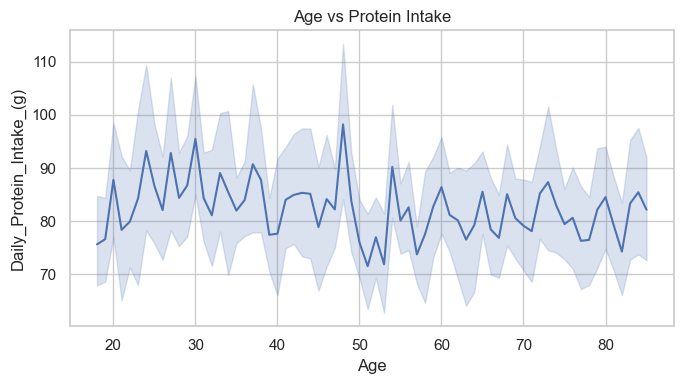

In [11]:
#Line Plot: Age vs Protein Intake
if column_exists('Age') and column_exists('Daily_Protein_Intake_(g)'):
    df_sorted = df.sort_values('Age')
    plt.figure(figsize=(7, 4))
    sns.lineplot(data=df_sorted, x='Age', y='Daily_Protein_Intake_(g)')
    plt.title("Age vs Protein Intake")
    plt.tight_layout()
    plt.show()


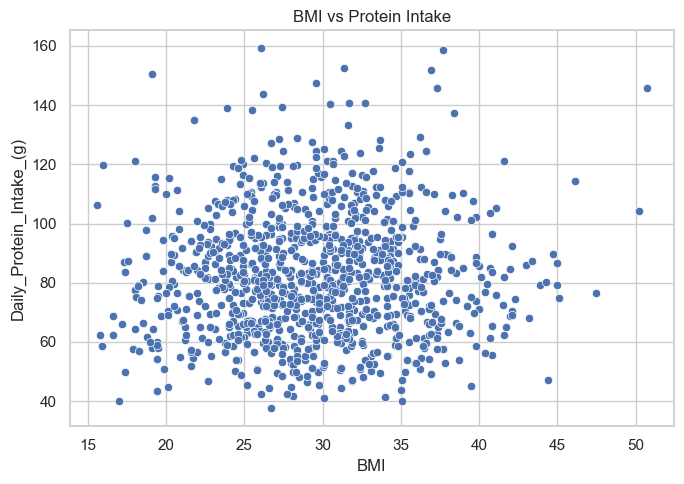

In [12]:
#Scatter Plot: BMI vs Protein Intake
if column_exists('BMI') and column_exists('Daily_Protein_Intake_(g)'):
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=df, x='BMI', y='Daily_Protein_Intake_(g)', hue='Gender' if 'Gender' in df else None)
    plt.title("BMI vs Protein Intake")
    plt.tight_layout()
    plt.show()

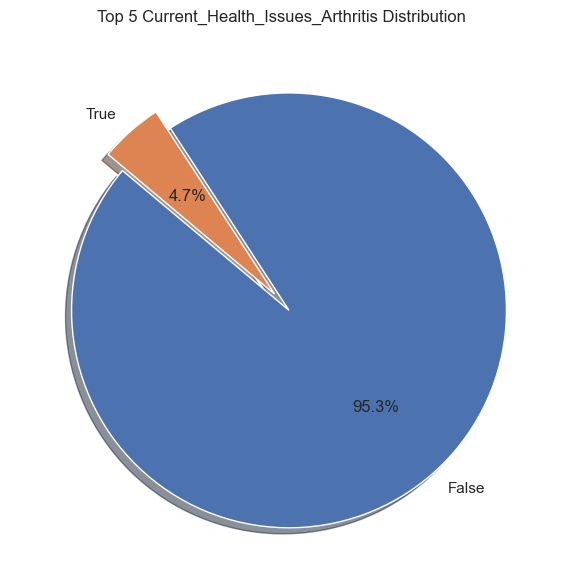

In [13]:
#Pie Chart: Top 5 Current Health Issues
health_col = next((col for col in df.columns if "health" in col.lower() and "issue" in col.lower()), None)

if health_col:
    top_issues = df[health_col].value_counts().dropna().head(5)

    if not top_issues.empty:
        plt.figure(figsize=(6, 6))
        top_issues.plot.pie(autopct='%1.1f%%', startangle=140, shadow=True, explode=[0.05]*len(top_issues))
        plt.title(f"Top 5 {health_col} Distribution")
        plt.ylabel("")
        plt.tight_layout()
        plt.show()

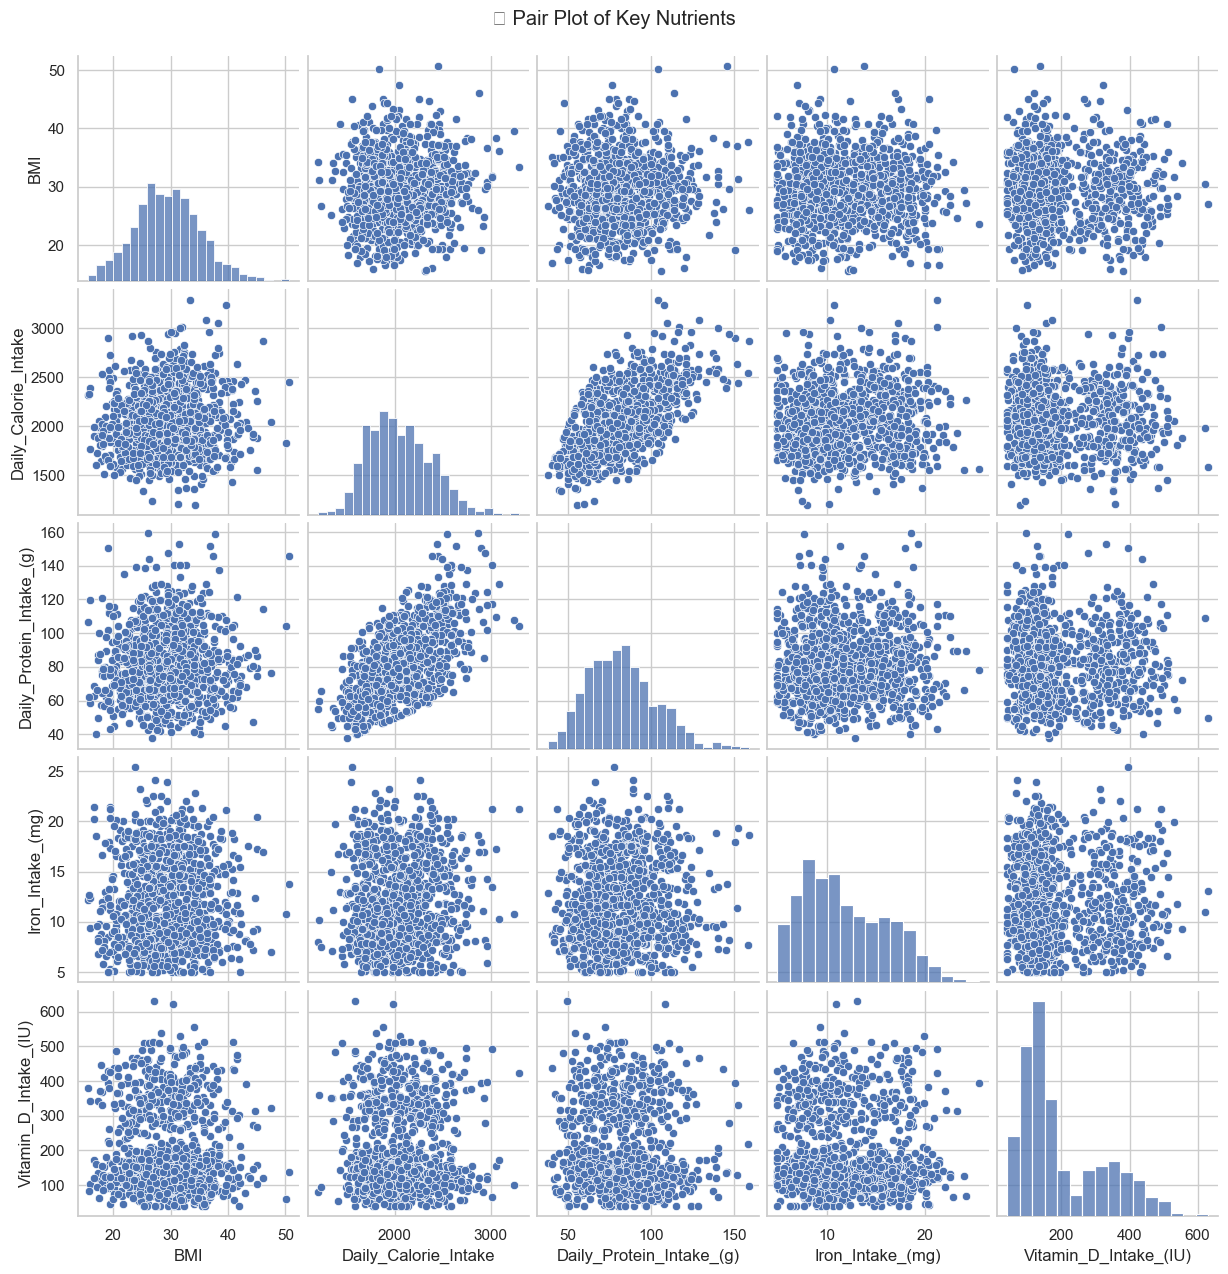

In [14]:
#Pair Plot: 5 Important Nutritional Factors
selected = ['BMI', 'Daily_Calorie_Intake', 'Daily_Protein_Intake_(g)', 'Iron_Intake_(mg)', 'Vitamin_D_Intake_(IU)']
existing_cols = [col for col in selected if column_exists(col)]
if len(existing_cols) >= 2:
    sns.pairplot(df[existing_cols])
    plt.suptitle("🌐 Pair Plot of Key Nutrients", y=1.02)
    plt.show()

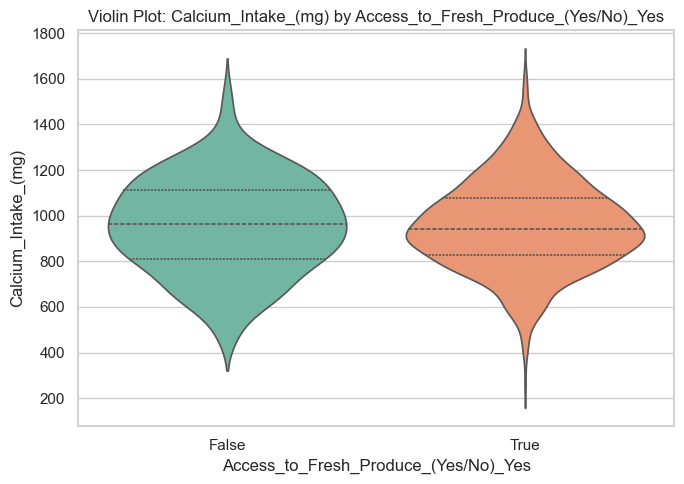

In [15]:
#Violin Plot: Calcium Intake by Access to Fresh Produce
access_col = next((col for col in df.columns if "access" in col.lower() and "produce" in col.lower()), None)
calcium_col = next((col for col in df.columns if "calcium" in col.lower()), None)

if access_col and calcium_col:
    filtered_df = df[[access_col, calcium_col]].dropna()

    if not filtered_df.empty and filtered_df[access_col].nunique() > 1:
        plt.figure(figsize=(7, 5))
        sns.violinplot(data=filtered_df, x=access_col, y=calcium_col, inner='quartile', palette='Set2')
        plt.title(f"Violin Plot: {calcium_col} by {access_col}")
        plt.tight_layout()
        plt.show()

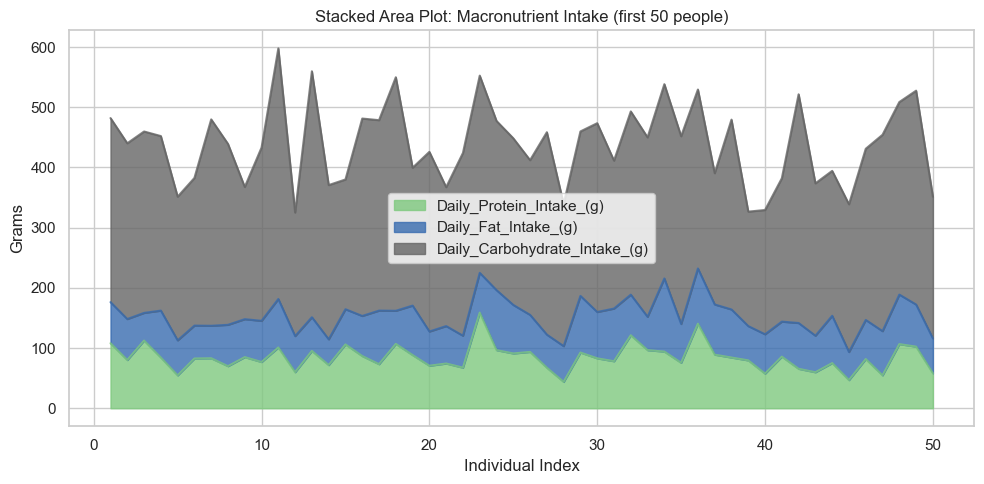

In [16]:
#Stacked Area Plot: Macronutrient Intake Breakdown
macro_cols = ['Daily_Protein_Intake_(g)', 'Daily_Fat_Intake_(g)', 'Daily_Carbohydrate_Intake_(g)']
macro_exists = all(column_exists(col) for col in macro_cols)
if macro_exists:
    df_macros = df[macro_cols].head(50)  # show only 50 for clarity
    df_macros.index = range(1, len(df_macros)+1)
    df_macros.plot.area(stacked=True, figsize=(10, 5), colormap='Accent', alpha=0.8)
    plt.title("Stacked Area Plot: Macronutrient Intake (first 50 people)")
    plt.xlabel("Individual Index")
    plt.ylabel("Grams")
    plt.tight_layout()
    plt.show()

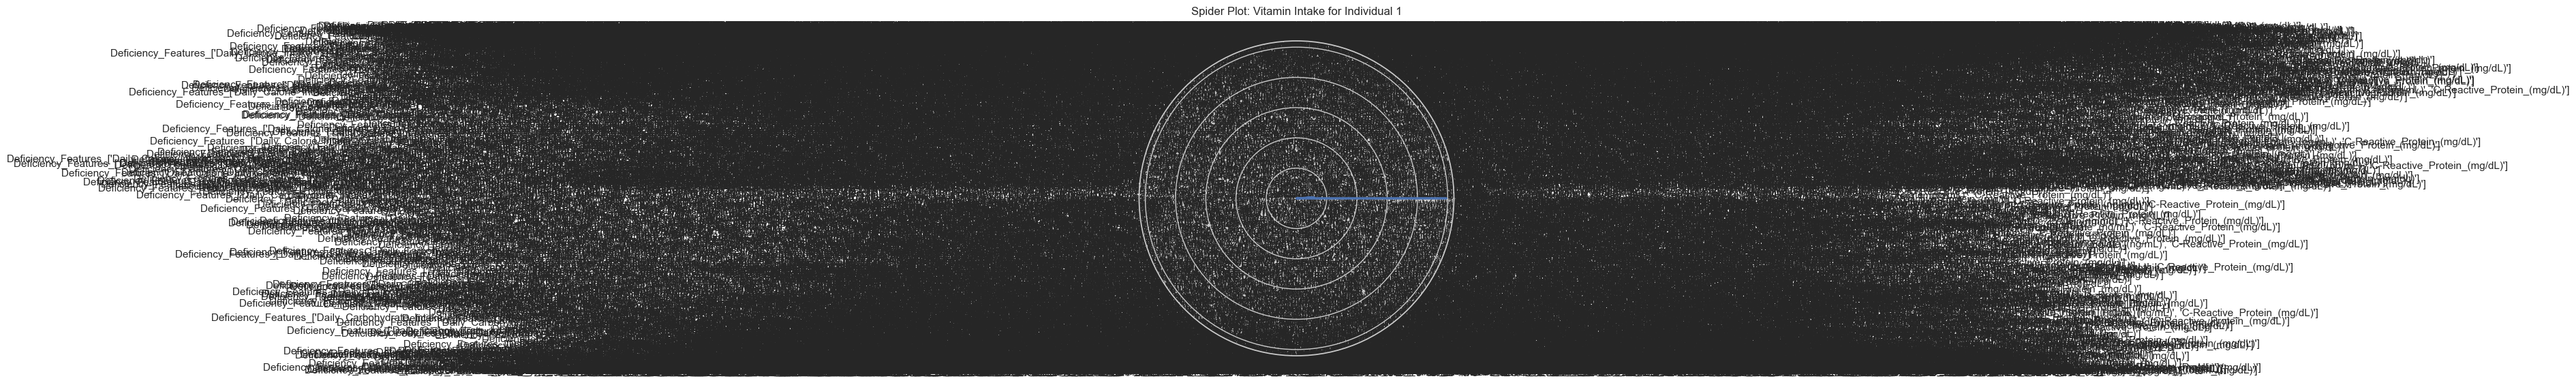

In [17]:
#Radar / Spider Plot: Comparing Multiple Vitamins
# Choose 1 sample person
sample = df.iloc[0]
vitamin_cols = [col for col in df.columns if "Vitamin_" in col and "Intake" in col]
values = sample[vitamin_cols].values.flatten().tolist()
labels = [col.replace('_Intake_(mg)', '').replace('_Intake_(mcg)', '').replace('Vitamin_', 'Vit ') for col in vitamin_cols]

# Normalize values for fair comparison
values = values + values[:1]
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, values, linewidth=2)
ax.fill(angles, values, alpha=0.25)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title("Spider Plot: Vitamin Intake for Individual 1")
plt.tight_layout()
plt.show()

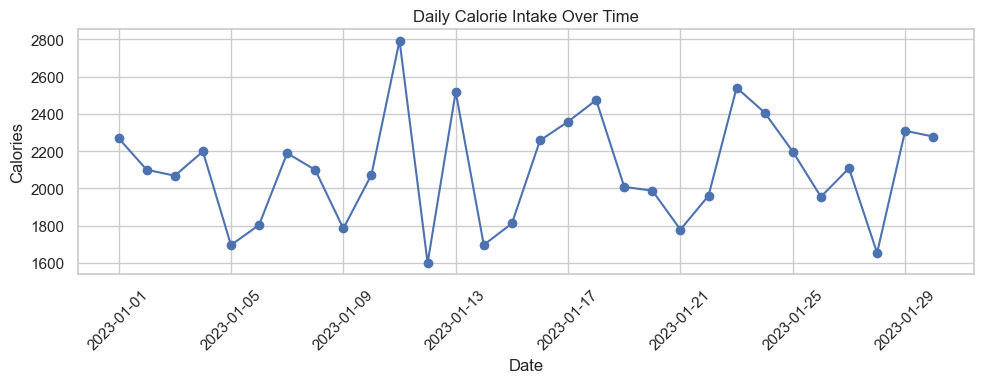

In [18]:
#Time Series Plot: Trends Over Time (Mock Example)
# Mock time series by assigning fake dates
df_time = df.copy().head(30)
df_time['Date'] = pd.date_range(start='2023-01-01', periods=30)

plt.figure(figsize=(10, 4))
plt.plot(df_time['Date'], df_time['Daily_Calorie_Intake'], marker='o')
plt.title("Daily Calorie Intake Over Time")
plt.xlabel("Date")
plt.ylabel("Calories")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



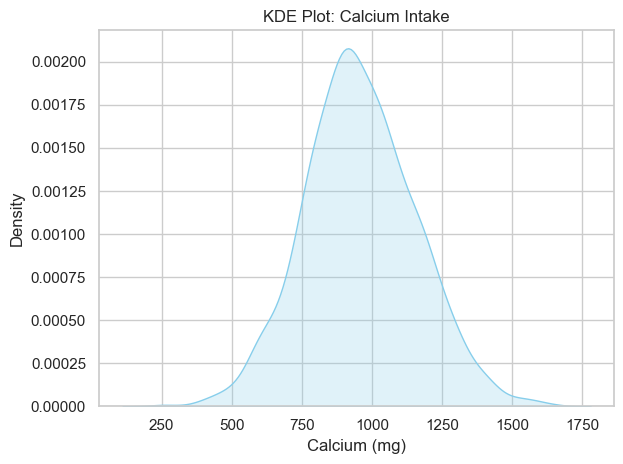

In [19]:
#KDE Plot: Calcium Intake
sns.kdeplot(df['Calcium_Intake_(mg)'], fill=True, color='skyblue')
plt.title("KDE Plot: Calcium Intake")
plt.xlabel("Calcium (mg)")
plt.tight_layout()
plt.show()



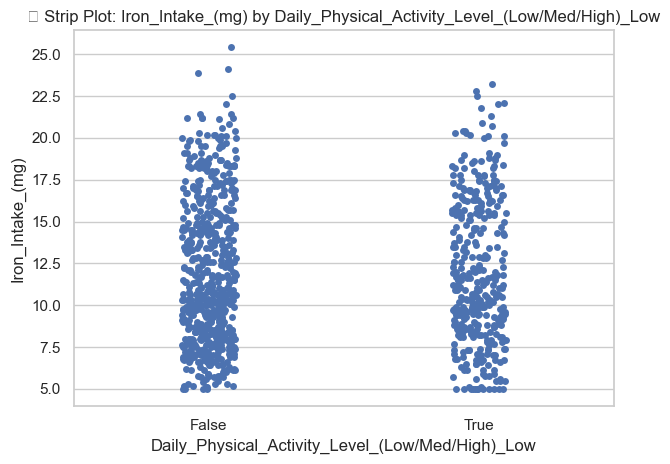

In [20]:
#Strip Plot: Iron Intake by Activity Level
activity_col = next((col for col in df.columns if "activity" in col.lower() and "level" in col.lower()), None)
iron_col = next((col for col in df.columns if "iron" in col.lower()), None)

if activity_col and iron_col:
    sns.stripplot(data=df, x=activity_col, y=iron_col, jitter=True)
    plt.title(f"🔹 Strip Plot: {iron_col} by {activity_col}")
    plt.tight_layout()
    plt.show()
else:
    print("Could not find activity level or iron intake columns.")



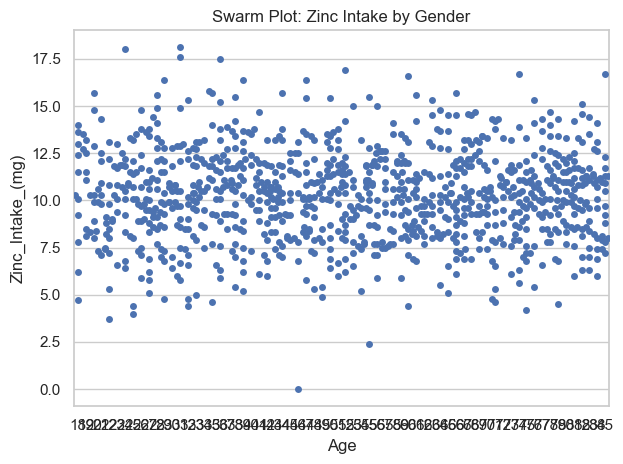

In [21]:
#Swarm Plot: Zinc Intake by Age
sns.swarmplot(data=df, x='Age', y='Zinc_Intake_(mg)', size=5)
plt.title("Swarm Plot: Zinc Intake by Gender")
plt.tight_layout()
plt.show()


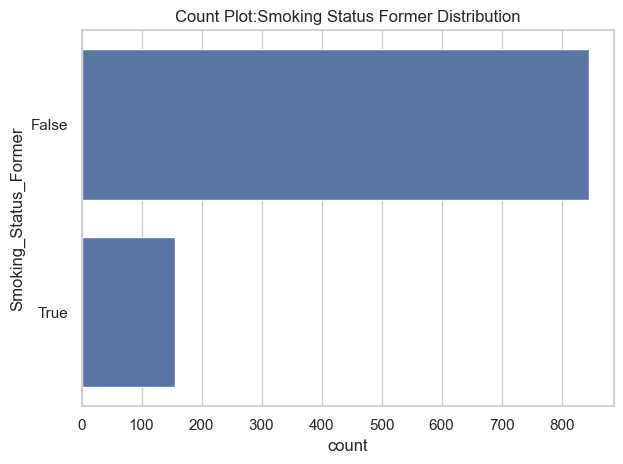

In [22]:
#Count Plot: Smoking Status
sns.countplot(data=df, y='Smoking_Status_Former', order=df['Smoking_Status_Former'].value_counts().index)
plt.title("Count Plot:Smoking Status Former Distribution")
plt.tight_layout()
plt.show()
